# Telecom Customer Churn Prediction and Retention Analytics System

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder,OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score,average_precision_score

import warnings
warnings.filterwarnings("ignore")

### Data loading and Exploring

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print ("Unique values :  \n",df.nunique())

Unique values :  
 customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

### Handling duplicte values

In [5]:
# NO duplicate values in data ,customerID has uique values
df.duplicated().sum()

0

In [6]:
# Dropping  customerID column
df=df.drop(columns=['customerID'])

In [7]:
# CHANGING DATA TYPE OF TotalCharges and handling null values
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

In [8]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

NULL VALUES in Total Charges with Tenure ZERO

In [9]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
# FILLING NULL VALUES IN TOTAL CHARGES WITH EXACT AMOUNT IN  MONTHLY CHARGES BECAUSE TENURE WAS ZERO
df["TotalCharges"]=df["TotalCharges"].fillna(df["MonthlyCharges"]* df["tenure"])

In [11]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [12]:
# CUSTOMERS WITH ZERO TENURE HAS NO NULL  values in TOTAL CAHRGES
df[df["tenure"]==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Feature Engineering

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# CUSTOMER WITH ZERO TENURE HAS ZERO TOTAL CHARGES  AND AVERAGE MONTHLY CHARGES
df["AvgMonthlySpend"] = np.where(df["tenure"] == 0,0,df["TotalCharges"] / df["tenure"])

In [16]:
# CUSTOMERS WITH TENURE LESS THAN 12 ARE NEW CUSTOMERS
df["IsNewCustomer"] = (df["tenure"] < 12).astype(int)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1


In [18]:
df[df["tenure"]==0].head(11)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No,0.0,1
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No,0.0,1
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No,0.0,1
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No,0.0,1
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No,0.0,1
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No,0.0,1
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No,0.0,1
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No,0.0,1
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No,0.0,1
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,No,Two year,No,Mailed check,73.35,0.0,No,0.0,1


In [19]:
df[df["tenure"]==1].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,1
20,Male,1,No,No,1,No,No phone service,DSL,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,39.65,1
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes,20.15,1
27,Male,0,Yes,Yes,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,No,Electronic check,30.20,30.20,Yes,30.20,1
33,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.20,20.20,No,20.20,1


In [20]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,IsNewCustomer
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.218275,-0.022396
tenure,0.016567,1.000000,0.247900,0.826178,0.249391,-0.736687
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.994355,-0.186611
TotalCharges,0.103006,0.826178,0.651174,1.000000,0.651435,-0.576747
AvgMonthlySpend,0.218275,0.249391,0.994355,0.651435,1.000000,-0.186720
IsNewCustomer,-0.022396,-0.736687,-0.186611,-0.576747,-0.186720,1.000000


* MonthlyCharges ↔ AvgMonthlySpend
* The Correlation between them is 0.957328

* AvgMonthlySpend is almost the same information as MonthlyCharges.
* It is not introducing much new information.
* Logistic Regression can suffer from multicollinearity when highly correlated features coexist.

* + AvgMonthlySpend was engineered from existing billing variables. Correlation analysis showed a very strong relationship with MonthlyCharges (0.957), indicating substantial overlap in information. To reduce multicollinearity and improve model interpretability, the feature was removed after confirming that model performance did not deteriorate.

* ====================================================================

* TotalCharges ↔ AvgMonthlySpend

* Correlation between them is 0.764489

* Strong positive correlation.
* Expected because TotalCharges is influenced by monthly spending.
* + IsNewCustomer was created to capture whether a customer is in the early stage of the customer lifecycle. Although derived from tenure, it provides a business-oriented categorical representation that may help the model capture non-linear tenure effects. The feature was retained and evaluated during model training.





In [21]:
# df.corr(method="pearson",numeric_only=True)
# df.corr(method="spearman",numeric_only=True)
# df.corr(method="kendall",numeric_only=True)

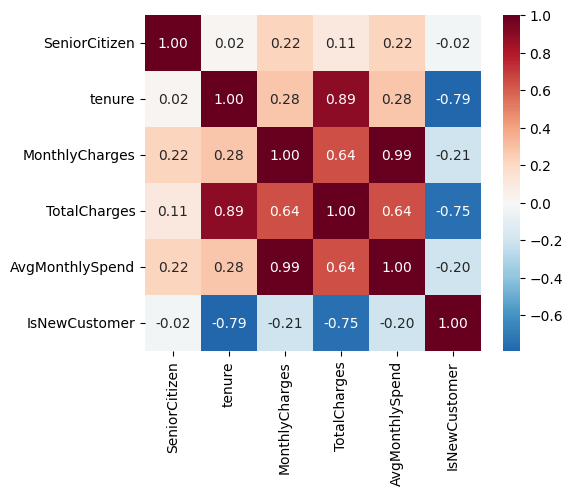

In [22]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df.corr(method="spearman", numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True
)
plt.tight_layout()
plt.show()

In [23]:
# DROPPED THE COLUMNS AvgMonthlySpend & IsNewCustomer
df=df.drop([ 'AvgMonthlySpend', 'IsNewCustomer'], axis=1)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# defining Target Column

In [25]:
# Encodeing values of the target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])  # No→0, Yes→1

In [26]:
df.shape

(7043, 20)

In [27]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [28]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [29]:
y.shape

(7043,)

In [30]:
y.value_counts(normalize=True)*100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

# Train Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

print(X.shape,y.shape)
print("-"*40)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(7043, 19) (7043,)
----------------------------------------
(5634, 19) (5634,) (1409, 19) (1409,)


In [32]:
df.shape

(7043, 20)

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# DATA PREPROCESSING

## Column declaration

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [35]:
# Numerical columns
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Binary categorical columns
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "SeniorCitizen"
]

# Nominal categorical columns
nominal_cols = [
    "gender",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

# Column Transformation

In [36]:
# Numerical pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler())
])

# Binary pipeline
binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
])

# Nominal pipeline
nominal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("bin", binary_transformer, binary_cols),
        ("nom", nominal_transformer, nominal_cols)
    ],
    remainder='drop'
)

In [37]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Partner', 'Depende...,
                                  'PaperlessBilling', 'SeniorCitizen']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies', 'Contract',
                                  'PaymentMethod'])])

# Pipeline

In [38]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",LogisticRegression(random_state=42,class_weight='balanced'))
])

## Hyperparameter

In [39]:
param_dist={
    "model__C":[0.0001,0.001,0.01,0.1,1,10,100,1000],
    "model__penalty":["l1","l2"],
    "model__solver":["liblinear","saga"]
}
# Small C → stronger regularization
# Large C → weaker regularization

# Hyperparameter Tuning

In [40]:
from sklearn.model_selection import RandomizedSearchCV

random_search=RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42
)

In [41]:
# ##To verify all valid parameter names
# # for param in random_search.get_params().keys():
# #     print(param)
# for param in model_pipeline.get_params().keys():
#     print(param)

In [42]:
# 1. Train model
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('bin',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OrdinalEncoder(handle_un...
                                                                                'DeviceProtection',
                                                                                'TechSupport',
                                                                                'StreamingTV',
                                                                                'StreamingMovies',
                                                                                'Contract',
                                                                                'PaymentMethod'])])),
                                             ('model',
                                              LogisticRegression(class_weight='balanced',
                                                                 random_state=42))]),
                   n_iter=20,
                   param_distributions={'model__C': [0.0001, 0.001, 0.01, 0.1,
                                                     1, 10, 100, 1000],
                                        'model__penalty': ['l1', 'l2'],
                                        'model__solver': ['liblinear', 'saga']},
                   random_state=42, scoring='roc_auc')


# Best_Score Best_Parameters Best_Estimators

In [43]:
# finding the best score
print("Best Score --- This is the mean CV score of the best hyperparameters:" )
print(random_search.best_score_)

# fetching the best parameters
print("Best Parameters:")
print(random_search.best_params_)

# using best estimator to create best model
best_model = random_search.best_estimator_
best_model

Best Score --- This is the mean CV score of the best hyperparameters:
0.8456271766047232
Best Parameters:
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 100}


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(C=100, class_weight='balanced',
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [44]:
print(best_model.named_steps.keys())

dict_keys(['preprocessor', 'model'])


## Get probability predictions

In [45]:
# [:, 1]-selects only the probability of Class 1 (Churn):
# y_prob contains the predicted probabilities:
# y_pred contains only 0s and 1s:

y_prob = best_model.predict_proba(X_test)[:, 1]
print("y_prob--->",y_prob)

y_prob---> [0.12418056 0.85094961 0.12291239 ... 0.3302722  0.01254848 0.0167048 ]


**THRESHOLD TUNING**

In [46]:
for threshold in [0.3,0.4,0.45,0.5,0.55,0.6,0.7]:
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print("accuracy:",accuracy_score(y_test,y_pred))
    print("Precision:", precision_score(y_test,y_pred))
    print("Recall:", recall_score(y_test,y_pred))
    print("F1:", f1_score(y_test,y_pred))


Threshold = 0.3
accuracy: 0.6529453513129879
Precision: 0.42874845105328374
Recall: 0.9251336898395722
F1: 0.5859441151566469

Threshold = 0.4
accuracy: 0.6969481902058198
Precision: 0.46208869814020026
Recall: 0.8636363636363636
F1: 0.6020503261882573

Threshold = 0.45
accuracy: 0.7224982256919801
Precision: 0.4868217054263566
Recall: 0.839572192513369
F1: 0.6162904808635917

Threshold = 0.5
accuracy: 0.7374024130589071
Precision: 0.503448275862069
Recall: 0.7807486631016043
F1: 0.6121593291404612

Threshold = 0.55
accuracy: 0.7508871540099361
Precision: 0.5213358070500927
Recall: 0.7513368983957219
F1: 0.615553121577218

Threshold = 0.6
accuracy: 0.7650816181689141
Precision: 0.5441478439425051
Recall: 0.7085561497326203
F1: 0.6155632984901278

Threshold = 0.7
accuracy: 0.7899219304471257
Precision: 0.6042780748663101
Recall: 0.6042780748663101
F1: 0.6042780748663101


In [47]:
# goal is to maximize Recall.
# analyzed different thresholds and found 0.45 works better.
# Lower threshold selected to improve churn recall.
# Catch as many churn customers as possible, even if some non-churn customers are incorrectly flagged.
# Missing a churn customer is costly.
threshold = 0.45
y_pred = (y_prob >= threshold).astype(int)
print("y_pred--->",y_pred)

y_pred---> [0 1 0 ... 0 0 0]


# METRICS

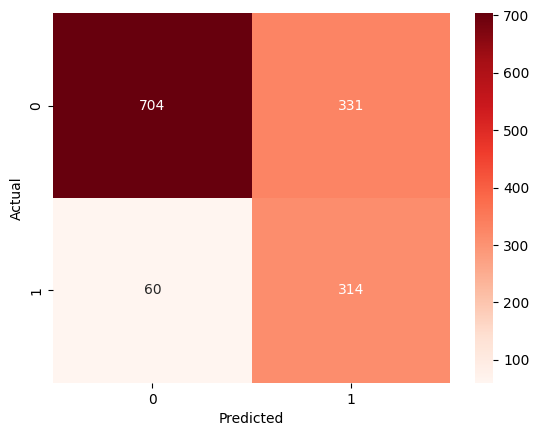

In [48]:
# sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='yellow')
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt='d',cmap='Reds' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Metrics

In [49]:
print("Confusion Matrix         \n",confusion_matrix(y_test, y_pred))
print("Accuracy----------------->",accuracy_score(y_test, y_pred))
print("Precision---------------->",precision_score(y_test, y_pred))
print("Recall------------------->",recall_score(y_test, y_pred))
print("F1 Score----------------->",f1_score(y_test, y_pred))
print("ROC-AUC------------------>",roc_auc_score(y_test, y_prob))
print("PR-AUC------------------->",average_precision_score(y_test, y_prob))
print("Classification Report  \n",classification_report(y_test, y_pred))

Confusion Matrix         
 [[704 331]
 [ 60 314]]
Accuracy-----------------> 0.7224982256919801
Precision----------------> 0.4868217054263566
Recall-------------------> 0.839572192513369
F1 Score-----------------> 0.6162904808635917
ROC-AUC------------------> 0.8404376243250924
PR-AUC-------------------> 0.6266001269748778
Classification Report  
               precision    recall  f1-score   support

           0       0.92      0.68      0.78      1035
           1       0.49      0.84      0.62       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.81      0.72      0.74      1409



# ROC_AUC Score

In [50]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8404376243250924


# PR_AUC Score

In [51]:
#Average Precision Score
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.6266001269748778


# ROC Curve & PR curve

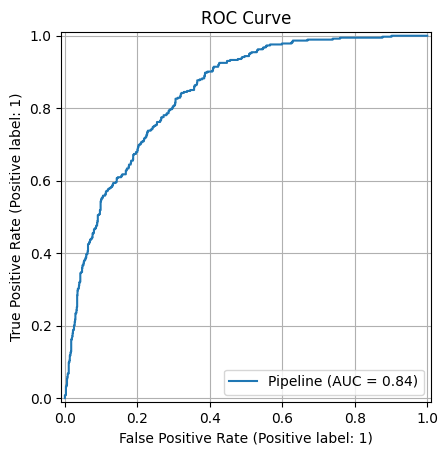

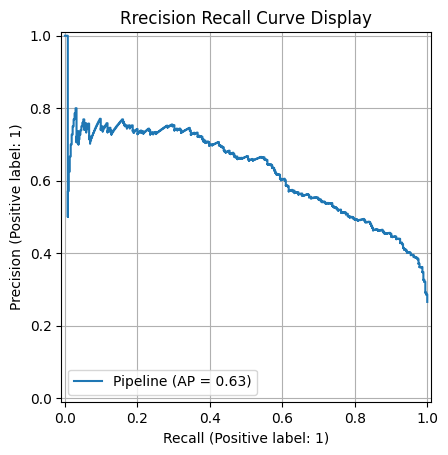

In [52]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.grid(True)
plt.show()

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Rrecision Recall Curve Display")
plt.grid(True)
plt.show()

# Feature Importance

In [53]:
lr=best_model.named_steps['model']

coefficients=lr.coef_[0]

feature_names=best_model.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({"Feature": feature_names,"Coefficient": coefficients})

coef_df.sort_values( by="Coefficient",ascending=False)

,Feature,Coefficient
11,nom__InternetService_Fiber optic,2.749168
24,nom__StreamingMovies_Yes,1.031221
22,nom__StreamingTV_Yes,1.006051
10,nom__MultipleLines_Yes,0.631062
2,num__TotalCharges,0.527286
28,nom__PaymentMethod_Electronic check,0.398496
18,nom__DeviceProtection_Yes,0.344753
6,bin__PaperlessBilling,0.332064
16,nom__OnlineBackup_Yes,0.230447
7,bin__SeniorCitizen,0.155750


In [56]:
import joblib
joblib.dump(best_model,'telecom_customer_churn_model_LR.pkl')

['telecom_customer_churn_model_LR.pkl']

In [55]:
# model = joblib.load('telecom_customer_churn_model_LR.pkl')
# predictions = model.predict()
# predictions